RQ3 

General Protective Behaviour - Early pandemic 

Feature Importance 

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import joblib


Feature Importance                                Feature  Importance
6     protective_behavior_nomask_scale    0.537673
9                 7days_rolling_deaths    0.064541
0               Non-household contacts    0.060295
10                      mandate_period    0.055243
8                  7days_rolling_cases    0.050785
24                      state_Victoria    0.046782
4                   Perceived Severity    0.046489
7                                 week    0.011360
17  Isolate if instructed_Very willing    0.010047
19               state_New South Wales    0.009729
1                                  age    0.009261
25             state_Western Australia    0.009165
5             Perceived Susceptibility    0.008389
12               Isolate if unwell_Yes    0.007134
21                    state_Queensland    0.006481


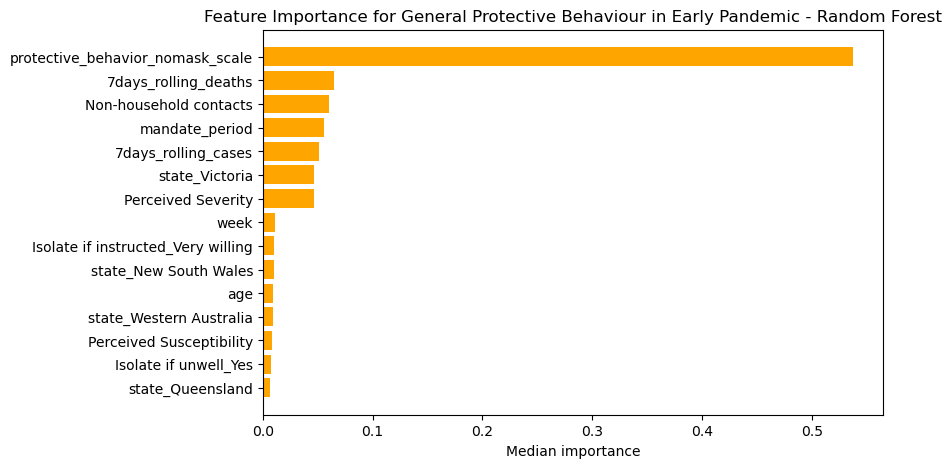

In [2]:
# downloadig data from the rf model code

# General Protective Behaviour early train set

early_train_general_behav = pd.read_csv("early_train_general_behav.csv")

# remove the target variables and identifiers
drop_cols = ['RecordNo', 'Date', 'face_mask_scale', 'face_mask_binary','general_protective_behavior_scale',
                'general_protective_behavior_binary','mandate_start_date', 'wave'] # wave 




# predictors
x_train = early_train_general_behav.drop(columns=drop_cols)
x_train = x_train.astype(float)  # converting boolean to float 


# target variable
y_train = early_train_general_behav["general_protective_behavior_binary"]


# best rf hyper parameters
best_parameters = joblib.load(f"RQ3_general_behav_early_RF_bestParameters_rolling.pkl")




# feature importance 


# to keep all the importances in each run
all_importances = []



# 100 runs for stability 
for i in range(100): 

    temp_rf = Pipeline([
        ('ros', RandomOverSampler(random_state=i)),
        ('rf', RandomForestClassifier(random_state=i,
                                      n_jobs=-1))
                                      ])

    temp_rf.set_params(**best_parameters)

    temp_rf.fit(x_train, y_train)

    all_importances.append(temp_rf.named_steps["rf"].feature_importances_)




all_importances = np.array(all_importances)

# take the median 
median_importance = np.median(all_importances, axis=0) # take the median of each column(feature) 


feature_importance = pd.DataFrame({
        "Feature": x_train.columns,
        "Importance": median_importance
    })

feature_importance = feature_importance.sort_values("Importance",ascending=False)



top15 = feature_importance.head(15)

print(f"Feature Importance",top15)

feature_importance.to_csv(f"RQ3_general_behav_early_RF_FeatureImportance_rolling.csv",index=False) # full feature importance list


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"], color="orange")
plt.title(f"Feature Importance for General Protective Behaviour in Early Pandemic - Random Forest")
plt.xlabel("Median importance")
plt.gca().invert_yaxis()
plt.savefig(f"RQ3_general_behav_early_RF_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
plt.show()
